# Mutual Fund Performance Analytics & Risk Modeling
**Dataset**: AMFI 40 Mutual Fund Schemes (Jan 2022 – May 2026)  
**Deliverables**: `Performance_Analytics.ipynb`, `fund_scorecard.csv`, `alpha_beta.csv`, `benchmark_comparison_chart.png`

---

## Executive Summary
This notebook performs comprehensive quantitative performance analytics, risk modeling, benchmark tracking error analysis, and composite scorecard ranking across **40 mutual fund schemes**. 

Key analytical components:
1. **Daily Returns & Distribution Validation**: Computing daily percentage returns and checking summary statistics, skewness, and kurtosis.
2. **CAGR Analysis (1yr, 3yr, 5yr)**: Annualized compounding growth rate across multiple investment horizons.
3. **Sharpe Ratio ($R_f = 6.5\%$)**: Risk-adjusted return measure ranking all 40 funds.
4. **Sortino Ratio**: Downside risk-adjusted return isolating negative return volatility.
5. **Alpha ($lpha$) & Beta ($eta$) OLS Regression**: Single-index capital market model regression against **NIFTY 100** benchmark returns using `scipy.stats.linregress`.
6. **Maximum Drawdown & Date Ranges**: Peak-to-trough worst-case loss analysis and date interval identification.
7. **Composite Fund Scorecard (0–100)**: Multi-factor ranking engine combining returns, Sharpe, Alpha, Expense Ratio, and Max Drawdown.
8. **Benchmark Comparison Chart & Tracking Error**: Rebased 3-year performance plot of Top 5 funds vs NIFTY 50 & NIFTY 100 with annualized tracking error.


## 1. Data Ingestion & Setup
We connect to the `bluestock_mf.db` SQLite database and load the scheme master metadata (`dim_fund`), daily NAV history (`fact_nav`), and benchmark index levels (`fact_benchmark_indices`).


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

# Connect to database
conn = sqlite3.connect('bluestock_mf.db')

df_fund = pd.read_sql('SELECT * FROM dim_fund', conn)
df_nav = pd.read_sql('SELECT * FROM fact_nav', conn)
df_bm = pd.read_sql('SELECT * FROM fact_benchmark_indices', conn)

df_nav['date'] = pd.to_datetime(df_nav['date'])
df_bm['date'] = pd.to_datetime(df_bm['date'])

print(f"Loaded {len(df_fund)} fund schemes.")
print(f"Loaded {len(df_nav)} NAV history records spanning {df_nav['date'].min().strftime('%Y-%m-%d')} to {df_nav['date'].max().strftime('%Y-%m-%d')}.")
print(f"Benchmark indices available: {df_bm['index_name'].unique().tolist()}")


Loaded 40 fund schemes.
Loaded 46000 NAV history records spanning 2022-01-03 to 2026-05-29.
Benchmark indices available: ['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']


## 2. Daily Return Computation & Distribution Validation
Daily percentage return is calculated as:
$$R_{i,t} = \frac{\text{NAV}_{i,t}}{\text{NAV}_{i,t-1}} - 1$$

We check distribution characteristics including mean, standard deviation, min, max, skewness, and kurtosis to validate that the return distribution is well-behaved and free of anomalies.


--- Daily Return Distribution Validation ---
Total Return Observations    45960.000000
Mean Daily Return (%)            0.063105
Std Daily Return (%)             1.029041
Min Daily Return (%)            -5.810201
25th Percentile (%)             -0.504211
Median Daily Return (%)          0.034021
75th Percentile (%)              0.632376
Max Daily Return (%)             6.471309
Skewness                         0.042676
Kurtosis (Excess)                1.367033


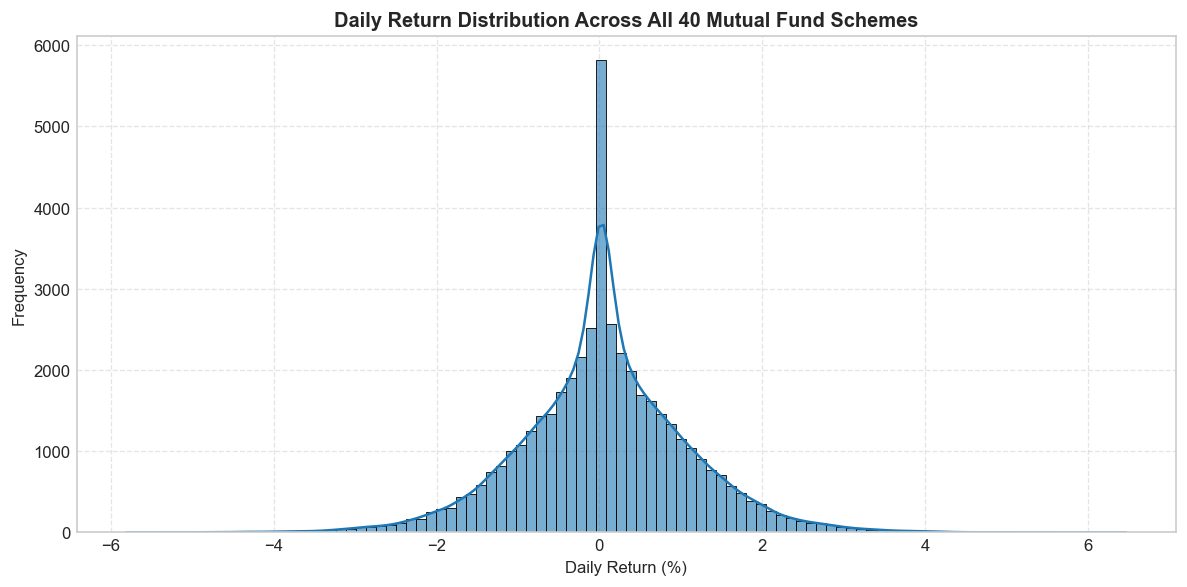

In [2]:
df_nav = df_nav.sort_values(['amfi_code', 'date'])
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# Aggregate statistics across all daily return data
all_returns = df_nav['daily_return'].dropna()

stats_summary = pd.Series({
    'Total Return Observations': len(all_returns),
    'Mean Daily Return (%)': all_returns.mean() * 100,
    'Std Daily Return (%)': all_returns.std() * 100,
    'Min Daily Return (%)': all_returns.min() * 100,
    '25th Percentile (%)': all_returns.quantile(0.25) * 100,
    'Median Daily Return (%)': all_returns.median() * 100,
    '75th Percentile (%)': all_returns.quantile(0.75) * 100,
    'Max Daily Return (%)': all_returns.max() * 100,
    'Skewness': stats.skew(all_returns),
    'Kurtosis (Excess)': stats.kurtosis(all_returns)
})

print("--- Daily Return Distribution Validation ---")
print(stats_summary.to_string())

# Plot Return Distribution
plt.figure(figsize=(10, 5))
sns.histplot(all_returns * 100, bins=100, kde=True, color='#1f77b4', edgecolor='black', alpha=0.6)
plt.title('Daily Return Distribution Across All 40 Mutual Fund Schemes', fontsize=12, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 3. CAGR Computation (1yr, 3yr, 5yr) & Fund Comparison
Compound Annual Growth Rate (CAGR) measures the annualized rate of investment growth:
$$\text{CAGR} = \left(\frac{\text{NAV}_{\text{end}}}{\text{NAV}_{\text{start}}}\right)^{\frac{1}{n}} - 1$$

* **1-Year CAGR**: $n = 1.0$ year (May 2025 – May 2026)
* **3-Year CAGR**: $n = 3.0$ years (May 2023 – May 2026)
* **5-Year CAGR**: Full historical dataset period ($n = 4.40$ years, Jan 2022 – May 2026)


In [3]:
end_date = df_nav['date'].max()
date_1yr = end_date - pd.DateOffset(years=1)
date_3yr = end_date - pd.DateOffset(years=3)
date_min = df_nav['date'].min()
n_5yr = (end_date - date_min).days / 365.25

rf_annual = 0.065 # 6.5% RBI repo rate proxy

# Benchmarks setup
df_n100 = df_bm[df_bm['index_name'] == 'NIFTY100'].sort_values('date').copy()
df_n100['bm100_return'] = df_n100['close_value'].pct_change()

df_n50 = df_bm[df_bm['index_name'] == 'NIFTY50'].sort_values('date').copy()
df_n50['bm50_return'] = df_n50['close_value'].pct_change()

metrics_list = []
alpha_beta_records = []

for amfi, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date').dropna(subset=['daily_return'])
    fund_info = df_fund[df_fund['amfi_code'] == amfi].iloc[0]
    
    nav_end = group[group['date'] == end_date]['nav'].values[0] if len(group[group['date'] == end_date]) > 0 else group['nav'].iloc[-1]
    
    # 1yr CAGR
    g_1yr = group[group['date'] >= date_1yr]
    cagr_1yr = (nav_end / g_1yr['nav'].iloc[0]) ** (1/1.0) - 1
    
    # 3yr CAGR
    g_3yr = group[group['date'] >= date_3yr]
    cagr_3yr = (nav_end / g_3yr['nav'].iloc[0]) ** (1/3.0) - 1
    
    # 5yr (Full period ~4.4yr) CAGR
    cagr_5yr = (nav_end / group['nav'].iloc[0]) ** (1/n_5yr) - 1
    
    # Annualized Return & Volatility
    ret_ann = group['daily_return'].mean() * 252
    vol_ann = group['daily_return'].std() * np.sqrt(252)
    
    # Sharpe Ratio
    sharpe = (ret_ann - rf_annual) / vol_ann
    
    # Sortino Ratio (Downside deviation)
    downside_vol = np.sqrt(np.mean(np.minimum(0, group['daily_return'])**2)) * np.sqrt(252)
    sortino = (ret_ann - rf_annual) / downside_vol
    
    # Alpha & Beta OLS vs NIFTY 100
    merged = pd.merge(group[['date', 'daily_return']], df_n100[['date', 'bm100_return']], on='date').dropna()
    slope, intercept, r_val, p_val, std_err = stats.linregress(merged['bm100_return'], merged['daily_return'])
    beta = slope
    alpha_ann = intercept * 252
    alpha_pct = alpha_ann * 100
    r_squared = r_val ** 2
    
    # Max Drawdown & Date Range
    group['running_max'] = group['nav'].cummax()
    group['drawdown'] = group['nav'] / group['running_max'] - 1
    min_dd = group['drawdown'].min()
    trough_row = group[group['drawdown'] == min_dd].iloc[0]
    trough_date = trough_row['date']
    peak_date = group[(group['date'] <= trough_date) & (group['nav'] == trough_row['running_max'])]['date'].max()
    
    metrics_list.append({
        'amfi_code': amfi,
        'scheme_name': fund_info['scheme_name'],
        'fund_house': fund_info['fund_house'],
        'category': fund_info['category'],
        'sub_category': fund_info['sub_category'],
        'expense_ratio_pct': fund_info['expense_ratio_pct'],
        'cagr_1yr_pct': cagr_1yr * 100,
        'cagr_3yr_pct': cagr_3yr * 100,
        'cagr_5yr_pct': cagr_5yr * 100,
        'ret_ann_pct': ret_ann * 100,
        'vol_ann_pct': vol_ann * 100,
        'sharpe_ratio': sharpe,
        'sortino_ratio': sortino,
        'alpha_annualized': alpha_ann,
        'alpha_pct': alpha_pct,
        'beta': beta,
        'r_squared': r_squared,
        'p_value': p_val,
        'max_drawdown_pct': min_dd * 100,
        'peak_date': peak_date.strftime('%Y-%m-%d'),
        'trough_date': trough_date.strftime('%Y-%m-%d')
    })

df_metrics = pd.DataFrame(metrics_list)

# Display CAGR comparison table
cagr_table = df_metrics[['amfi_code', 'scheme_name', 'sub_category', 'cagr_1yr_pct', 'cagr_3yr_pct', 'cagr_5yr_pct']].sort_values('cagr_3yr_pct', ascending=False)
print("--- CAGR Comparison Table Across All 40 Funds (Top 10 by 3yr CAGR) ---")
print(cagr_table.head(10).to_string(index=False))


--- CAGR Comparison Table Across All 40 Funds (Top 10 by 3yr CAGR) ---
amfi_code                                        scheme_name sub_category  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
   119094                Axis Midcap Fund - Regular - Growth      Mid Cap     22.261065     35.111802     28.319478
   148567      Mirae Asset Large Cap Fund - Regular - Growth    Large Cap     20.360678     34.000916     30.405764
   120504          ICICI Pru Bluechip Fund - Direct - Growth    Large Cap     13.064279     32.487429     23.618738
   100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth      Mid Cap     53.232396     32.442459     30.520587
   120505           ICICI Pru Midcap Fund - Regular - Growth      Mid Cap     29.604659     31.777537     33.435620
   119551          SBI Bluechip Fund - Regular Plan - Growth    Large Cap     60.437341     30.456524     25.824779
   120843             Kotak Flexicap Fund - Regular - Growth    Flexi Cap     26.657082     29.582770     30.373084
 

## 4. Sharpe & Sortino Ratios Ranking
- **Sharpe Ratio**:
$$\text{Sharpe} = \frac{R_p - R_f}{\sigma_p \times \sqrt{252}}$$
where $R_f = 6.5\%$ per annum.

- **Sortino Ratio**:
$$\text{Sortino} = \frac{R_p - R_f}{\sigma_{\text{downside}} \times \sqrt{252}}$$
where $\sigma_{\text{downside}}$ measures standard deviation of negative daily return days only.


In [4]:
# Rank Funds by Sharpe Ratio
df_metrics['sharpe_rank'] = df_metrics['sharpe_ratio'].rank(ascending=False, method='min').astype(int)
df_metrics['sortino_rank'] = df_metrics['sortino_ratio'].rank(ascending=False, method='min').astype(int)

sharpe_table = df_metrics[['sharpe_rank', 'amfi_code', 'scheme_name', 'sub_category', 'sharpe_ratio', 'sortino_ratio', 'vol_ann_pct']].sort_values('sharpe_rank')

print("--- Top 10 Schemes by Sharpe Ratio ---")
print(sharpe_table.head(10).to_string(index=False))


--- Top 10 Schemes by Sharpe Ratio ---
 sharpe_rank amfi_code                                        scheme_name sub_category  sharpe_ratio  sortino_ratio  vol_ann_pct
           1    148567      Mirae Asset Large Cap Fund - Regular - Growth    Large Cap      1.448291       2.228568    14.193707
           2    120843             Kotak Flexicap Fund - Regular - Growth    Flexi Cap      1.306744       2.060951    15.886987
           3    148569      Mirae Asset Tax Saver Fund - Regular - Growth         ELSS      1.234930       1.911980    17.674007
           4    119551          SBI Bluechip Fund - Regular Plan - Growth    Large Cap      1.208267       1.886862    13.741434
           5    120505           ICICI Pru Midcap Fund - Regular - Growth      Mid Cap      1.180101       1.815148    19.290949
           6    149323                 DSP Midcap Fund - Regular - Growth      Mid Cap      1.132122       1.701217    17.746159
           7    100033 HDFC Mid-Cap Opportunities Fund - R

## 5. Alpha & Beta (OLS Regression vs NIFTY 100)
We run an Ordinary Least Squares (OLS) linear regression of fund daily returns on **NIFTY 100** daily returns using `scipy.stats.linregress`:
$$R_{\text{fund}, t} = \alpha_{\text{daily}} + \beta \times R_{\text{NIFTY100}, t} + \epsilon_t$$

* **Beta ($eta$)**: Systematic market exposure (slope).
* **Alpha ($lpha$)**: Annualized excess return ($	ext{intercept} \times 252$).

Results are exported to `alpha_beta.csv`.


In [5]:
df_ab_export = df_metrics[['amfi_code', 'scheme_name', 'category', 'sub_category', 'alpha_annualized', 'alpha_pct', 'beta', 'r_squared', 'p_value']]
df_ab_export.to_csv('alpha_beta.csv', index=False)
print("Saved alpha_beta.csv with 40 fund records.")

print("--- Alpha & Beta Summary Table (Top 10 Funds by Alpha %) ---")
print(df_ab_export.sort_values('alpha_pct', ascending=False).head(10).to_string(index=False))


Saved alpha_beta.csv with 40 fund records.
--- Alpha & Beta Summary Table (Top 10 Funds by Alpha %) ---
amfi_code                                        scheme_name category sub_category  alpha_annualized  alpha_pct      beta    r_squared  p_value
   119598         SBI Small Cap Fund - Regular Plan - Growth   Equity    Small Cap          0.303370  30.336965 -0.023196 1.414258e-04 0.687179
   149324              DSP Small Cap Fund - Regular - Growth   Equity    Small Cap          0.300579  30.057878  0.011455 3.532991e-05 0.840494
   120505           ICICI Pru Midcap Fund - Regular - Growth   Equity      Mid Cap          0.292636  29.263583  0.000549 1.345534e-07 0.990090
   148569      Mirae Asset Tax Saver Fund - Regular - Growth   Equity         ELSS          0.282704  28.270368  0.018134 1.748889e-04 0.654295
   120843             Kotak Flexicap Fund - Regular - Growth   Equity    Flexi Cap          0.273305  27.330465 -0.022830 3.430543e-04 0.530528
   100033 HDFC Mid-Cap Opportuni

## 6. Maximum Drawdown & Peak-to-Trough Date Ranges
Maximum Drawdown represents the peak-to-trough decline during a specific period:
$$\text{Drawdown}_t = \frac{\text{NAV}_t}{\text{Running\_Max}_t} - 1$$
$$\text{Max Drawdown} = \min_t (\text{Drawdown}_t)$$


In [6]:
dd_table = df_metrics[['amfi_code', 'scheme_name', 'sub_category', 'max_drawdown_pct', 'peak_date', 'trough_date']].sort_values('max_drawdown_pct', ascending=True)

print("--- Worst Maximum Drawdowns Across All Schemes (Top 10 Severe Losses) ---")
print(dd_table.head(10).to_string(index=False))


--- Worst Maximum Drawdowns Across All Schemes (Top 10 Severe Losses) ---
amfi_code                                    scheme_name sub_category  max_drawdown_pct  peak_date trough_date
   119599      SBI Small Cap Fund - Direct Plan - Growth    Small Cap        -52.574221 2023-01-17  2025-10-28
   119095         Axis Small Cap Fund - Regular - Growth    Small Cap        -51.677754 2025-05-22  2026-05-11
   101207         ABSL Small Cap Fund - Regular - Growth    Small Cap        -35.446916 2024-11-21  2026-05-11
   149324          DSP Small Cap Fund - Regular - Growth    Small Cap        -31.171900 2024-05-03  2025-01-03
   119598     SBI Small Cap Fund - Regular Plan - Growth    Small Cap        -28.706006 2024-08-28  2025-05-14
   102886            UTI Mid Cap Fund - Regular - Growth      Mid Cap        -28.001124 2025-01-07  2026-04-27
   100016      HDFC Top 100 Fund - Regular Plan - Growth    Large Cap        -24.734441 2022-03-30  2022-09-15
   120842  Kotak Emerging Equity Fund 

## 7. Composite Fund Scorecard (0–100)
We construct a composite 0–100 scorecard weighting five core performance dimensions:
* **30%** × 3-Year CAGR Return Rank Score
* **25%** × Sharpe Ratio Rank Score
* **20%** × Alpha Rank Score
* **15%** × Expense Ratio Rank Score (Inverse: lower fees yield higher score)
* **10%** × Max Drawdown Rank Score (Inverse: smaller loss magnitude yields higher score)

Component scores are normalized to a percentile scale $0 \le \text{Score} \le 100$:
$$\text{Score}_{i} = \frac{\text{Rank}_i - 1}{N - 1} \times 100$$

Composite score results are saved to `fund_scorecard.csv`.


In [7]:
N = len(df_metrics)

# 1. 3yr Return
df_metrics['rank_3yr'] = df_metrics['cagr_3yr_pct'].rank(ascending=True)
df_metrics['score_3yr'] = (df_metrics['rank_3yr'] - 1) / (N - 1) * 100

# 2. Sharpe Ratio
df_metrics['rank_sharpe'] = df_metrics['sharpe_ratio'].rank(ascending=True)
df_metrics['score_sharpe'] = (df_metrics['rank_sharpe'] - 1) / (N - 1) * 100

# 3. Alpha
df_metrics['rank_alpha'] = df_metrics['alpha_pct'].rank(ascending=True)
df_metrics['score_alpha'] = (df_metrics['rank_alpha'] - 1) / (N - 1) * 100

# 4. Expense Ratio (lower expense = higher score)
df_metrics['rank_expense'] = df_metrics['expense_ratio_pct'].rank(ascending=False)
df_metrics['score_expense'] = (df_metrics['rank_expense'] - 1) / (N - 1) * 100

# 5. Max Drawdown (less negative/smaller loss = higher score)
df_metrics['rank_max_dd'] = df_metrics['max_drawdown_pct'].rank(ascending=True)
df_metrics['score_max_dd'] = (df_metrics['rank_max_dd'] - 1) / (N - 1) * 100

# Composite Score
df_metrics['composite_score'] = (
    0.30 * df_metrics['score_3yr'] +
    0.25 * df_metrics['score_sharpe'] +
    0.20 * df_metrics['score_alpha'] +
    0.15 * df_metrics['score_expense'] +
    0.10 * df_metrics['score_max_dd']
)

df_metrics['fund_rank'] = df_metrics['composite_score'].rank(ascending=False, method='min').astype(int)
df_metrics = df_metrics.sort_values('fund_rank')

# Save fund_scorecard.csv
df_metrics.to_csv('fund_scorecard.csv', index=False)
print("Saved fund_scorecard.csv successfully.")

print("--- Top 10 Mutual Funds by Composite Scorecard (0-100) ---")
display_cols = ['fund_rank', 'amfi_code', 'scheme_name', 'sub_category', 'composite_score', 'cagr_3yr_pct', 'sharpe_ratio', 'alpha_pct', 'expense_ratio_pct', 'max_drawdown_pct']
print(df_metrics[display_cols].head(10).to_string(index=False))


Saved fund_scorecard.csv successfully.
--- Top 10 Mutual Funds by Composite Scorecard (0-100) ---
 fund_rank amfi_code                                        scheme_name sub_category  composite_score  cagr_3yr_pct  sharpe_ratio  alpha_pct  expense_ratio_pct  max_drawdown_pct
         1    148567      Mirae Asset Large Cap Fund - Regular - Growth    Large Cap        85.897436     34.000916      1.448291  26.983751               1.46        -11.265729
         2    120505           ICICI Pru Midcap Fund - Regular - Growth      Mid Cap        81.794872     31.777537      1.180101  29.263583               1.36        -18.188514
         3    120843             Kotak Flexicap Fund - Regular - Growth    Flexi Cap        81.538462     29.582770      1.306744  27.330465               1.45        -12.973968
         4    100033 HDFC Mid-Cap Opportunities Fund - Regular - Growth      Mid Cap        80.256410     32.442459      1.093699  27.195355               1.38        -16.217209
         5  

## 8. Benchmark Comparison Chart & Tracking Error
We select the **Top 5 Funds** based on the composite Fund Scorecard, rebase their NAVs to 100 on May 29, 2023 (3 years prior to end date), and compare their trajectories against **NIFTY 50** and **NIFTY 100**.

Tracking Error against benchmark is computed as:
$$\text{Tracking Error} = \sigma(R_{\text{fund}} - R_{\text{benchmark}}) \times \sqrt{252}$$


--- Tracking Error of Top 5 Funds Over 3 Years ---
Fund 148567 (Mirae Asset Large Cap Fund - Regular - Growth):
   Tracking Error vs NIFTY 100 = 18.80%
   Tracking Error vs NIFTY 50  = 19.19%

Fund 120505 (ICICI Pru Midcap Fund - Regular - Growth):
   Tracking Error vs NIFTY 100 = 23.27%
   Tracking Error vs NIFTY 50  = 22.84%

Fund 120843 (Kotak Flexicap Fund - Regular - Growth):
   Tracking Error vs NIFTY 100 = 20.65%
   Tracking Error vs NIFTY 50  = 20.51%

Fund 100033 (HDFC Mid-Cap Opportunities Fund - Regular - Growth):
   Tracking Error vs NIFTY 100 = 22.50%
   Tracking Error vs NIFTY 50  = 22.82%

Fund 120504 (ICICI Pru Bluechip Fund - Direct - Growth):
   Tracking Error vs NIFTY 100 = 18.73%
   Tracking Error vs NIFTY 50  = 18.82%



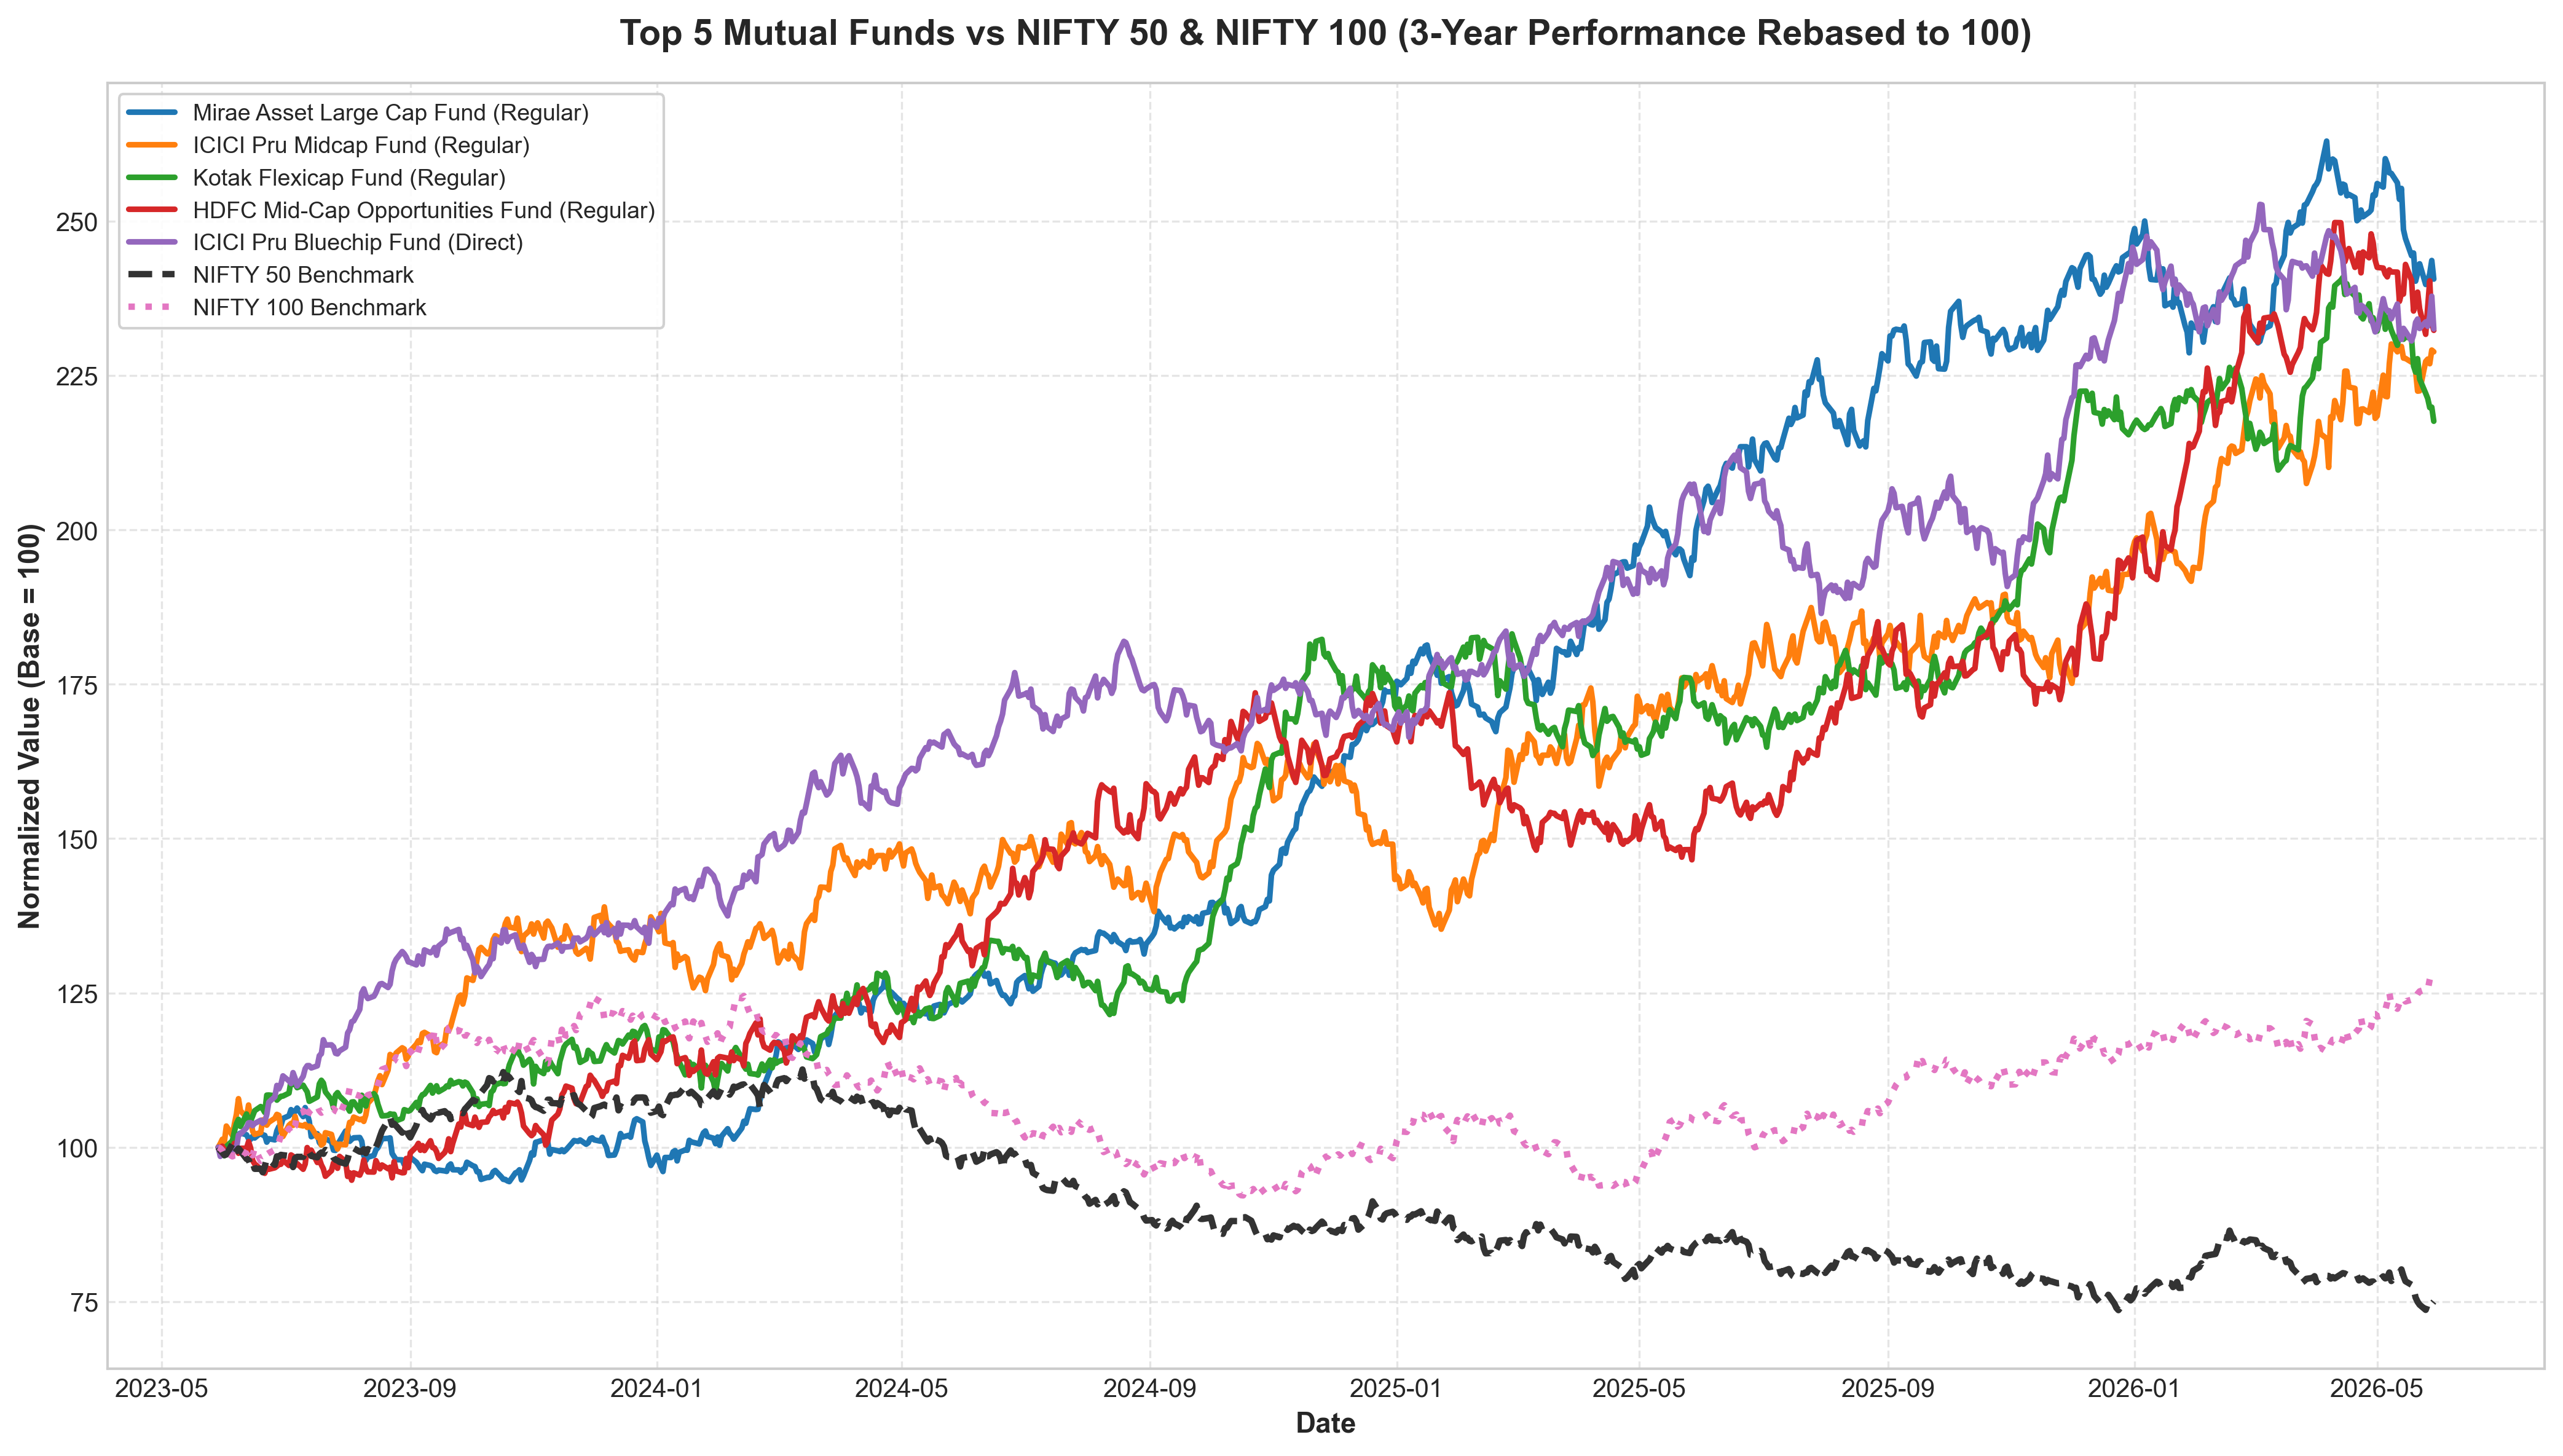

In [8]:
top5_df = df_metrics.head(5)
top5_codes = top5_df['amfi_code'].tolist()

df_3yr = df_nav[df_nav['date'] >= date_3yr].copy()
df_3yr['daily_return'] = df_3yr.groupby('amfi_code')['nav'].pct_change()

print("--- Tracking Error of Top 5 Funds Over 3 Years ---")
for code in top5_codes:
    sub = df_3yr[df_3yr['amfi_code'] == code].dropna(subset=['daily_return'])
    m100 = pd.merge(sub, df_n100, on='date').dropna()
    m50 = pd.merge(sub, df_n50, on='date').dropna()
    
    te_100 = (m100['daily_return'] - m100['bm100_return']).std() * np.sqrt(252)
    te_50 = (m50['daily_return'] - m50['bm50_return']).std() * np.sqrt(252)
    
    sname = df_fund[df_fund['amfi_code'] == code]['scheme_name'].iloc[0]
    print(f"Fund {code} ({sname}):")
    print(f"   Tracking Error vs NIFTY 100 = {te_100 * 100:.2f}%")
    print(f"   Tracking Error vs NIFTY 50  = {te_50 * 100:.2f}%\n")

# Plot Benchmark Comparison Chart
plt.figure(figsize=(14, 8), dpi=300)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, code in enumerate(top5_codes):
    fund_nav = df_3yr[df_3yr['amfi_code'] == code].sort_values('date')
    base_val = fund_nav['nav'].iloc[0]
    norm_nav = (fund_nav['nav'] / base_val) * 100
    sname = df_fund[df_fund['amfi_code'] == code]['scheme_name'].iloc[0]
    parts = sname.split(' - ')
    short_name = parts[0] + ' (' + parts[1] + ')' if len(parts) > 1 else sname
    plt.plot(fund_nav['date'], norm_nav, label=f'{short_name}', linewidth=2.2, color=colors[idx])

# Benchmarks
n50_3yr = df_bm[(df_bm['index_name'] == 'NIFTY50') & (df_bm['date'] >= date_3yr)].sort_values('date')
base_n50 = n50_3yr['close_value'].iloc[0]
norm_n50 = (n50_3yr['close_value'] / base_n50) * 100
plt.plot(n50_3yr['date'], norm_n50, label='NIFTY 50 Benchmark', linewidth=2.5, color='#333333', linestyle='--')

n100_3yr = df_bm[(df_bm['index_name'] == 'NIFTY100') & (df_bm['date'] >= date_3yr)].sort_values('date')
base_n100 = n100_3yr['close_value'].iloc[0]
norm_n100 = (n100_3yr['close_value'] / base_n100) * 100
plt.plot(n100_3yr['date'], norm_n100, label='NIFTY 100 Benchmark', linewidth=2.5, color='#e377c2', linestyle=':')

plt.title('Top 5 Mutual Funds vs NIFTY 50 & NIFTY 100 (3-Year Performance Rebased to 100)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11, fontweight='bold')
plt.ylabel('Normalized Value (Base = 100)', fontsize=11, fontweight='bold')
plt.legend(fontsize=9, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('benchmark_comparison_chart.png', dpi=300)
plt.savefig('notebooks/benchmark_comparison_chart.png', dpi=300)
plt.show()
